Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [2]:
# Load the dataset from the local file
file_path = r"C:\Users\ADMIN\Desktop\Assignment\hotel_bookings.csv"
df = pd.read_csv(file_path)


Initial Exploration

In [3]:
# Initial exploration
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nData types and missing values:")
display(df.info())

print("\nDescriptive statistics:")
display(df.describe(include='all'))

Dataset shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,03-07-15



Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-nul

None


Descriptive statistics:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,21-10-15
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


Data Cleaning and Preprocessing

In [4]:
# Convert date columns to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['arrival_date_year'] = df['arrival_date_year'].astype(str)
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'] + '-' + 
    df['arrival_date_month'] + '-' + 
    df['arrival_date_day_of_month'].astype(str)
)

# Create a total_stay feature
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Create total_guests feature
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# Create revenue feature (assuming ADR is average daily rate)
df['revenue'] = df['adr'] * df['total_stay']

# Handle missing values
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# Convert categoricals
categorical_cols = ['hotel', 'meal', 'country', 'market_segment', 
                   'distribution_channel', 'reserved_room_type',
                   'assigned_room_type', 'deposit_type', 'customer_type']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Create is_canceled flag (for easier analysis)
df['is_canceled'] = df['reservation_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

print("Data cleaning complete. New features created:")
display(df[['total_stay', 'total_guests', 'revenue', 'is_canceled']].head())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16536\1433721209.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])


Data cleaning complete. New features created:


,total_stay,total_guests,revenue,is_canceled
0,0,2.0,0.0,0
1,0,2.0,0.0,0
2,1,1.0,75.0,0
3,1,1.0,75.0,0
4,2,2.0,196.0,0


Analytics Implementation

1) Revenue Trends over Time

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16536\803961489.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_revenue = df.groupby([df['arrival_date'].dt.to_period('M'), 'hotel'])['revenue'].sum().unstack()


<Figure size 1400x700 with 0 Axes>

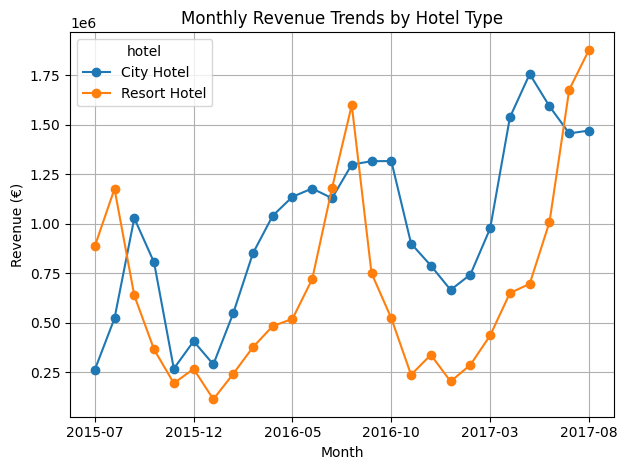

In [5]:
# Monthly revenue trends
monthly_revenue = df.groupby([df['arrival_date'].dt.to_period('M'), 'hotel'])['revenue'].sum().unstack()
monthly_revenue.index = monthly_revenue.index.astype(str)

plt.figure(figsize=(14, 7))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trends by Hotel Type')
plt.xlabel('Month')
plt.ylabel('Revenue (€)')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_revenue_trends.png')
plt.show()

2) Cancellation Rate Analysis

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16536\815955555.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100


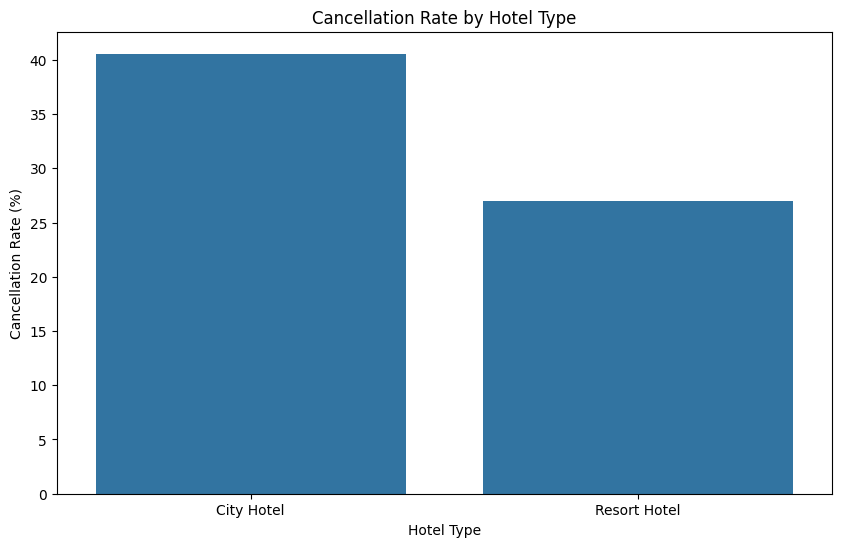

Overall Cancellation Rate: 36.03%


In [6]:
# Cancellation rate as percentage of total bookings
total_bookings = len(df)
canceled_bookings = df['is_canceled'].sum()
cancellation_rate = (canceled_bookings / total_bookings) * 100

# Cancellation rate by hotel type
cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=cancel_by_hotel.index, y=cancel_by_hotel.values)
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Hotel Type')
plt.savefig('cancellation_rate.png')
plt.show()

print(f"Overall Cancellation Rate: {cancellation_rate:.2f}%")

3) Geographical Distribution of Users

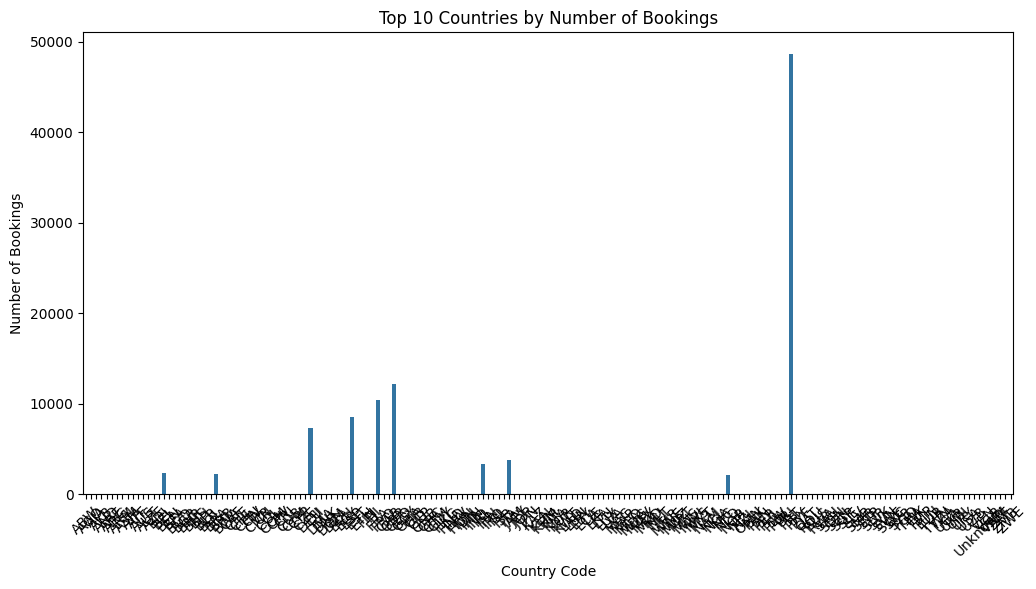

In [7]:
# Top 10 countries by bookings
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title('Top 10 Countries by Number of Bookings')
plt.xlabel('Country Code')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.savefig('geographical_distribution.png')
plt.show()

# For a more detailed view, we could use a world map (would require plotly or similar)

4) Booking Lead Time Distribution

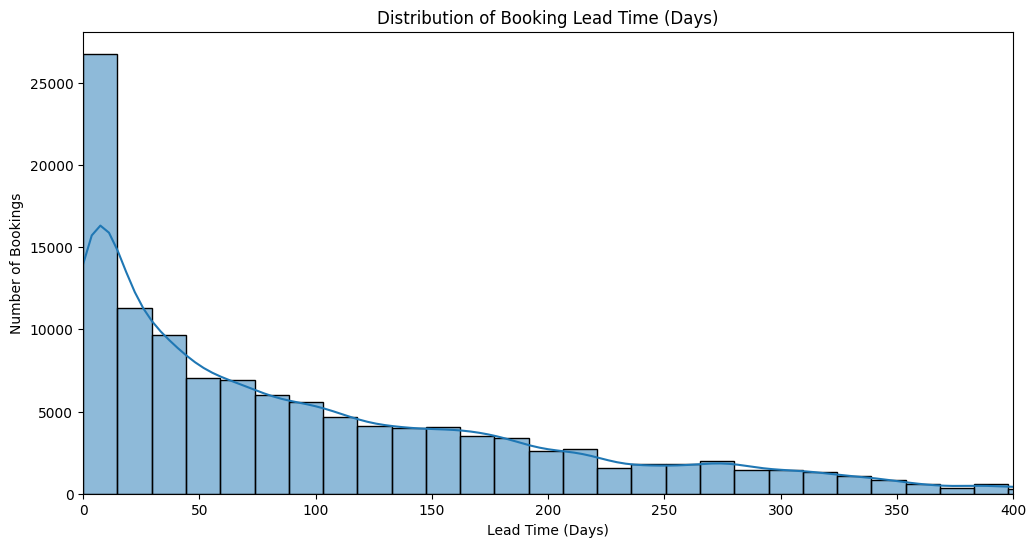

Average lead time: 104.01 days
Median lead time: 69.00 days


In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title('Distribution of Booking Lead Time (Days)')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')
plt.xlim(0, 400)  # Remove extreme outliers for better visualization
plt.savefig('lead_time_distribution.png')
plt.show()

print(f"Average lead time: {df['lead_time'].mean():.2f} days")
print(f"Median lead time: {df['lead_time'].median():.2f} days")

5) Additional Analytics

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16536\3205040469.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = df.groupby('market_segment')['revenue'].sum().sort_values(ascending=False)


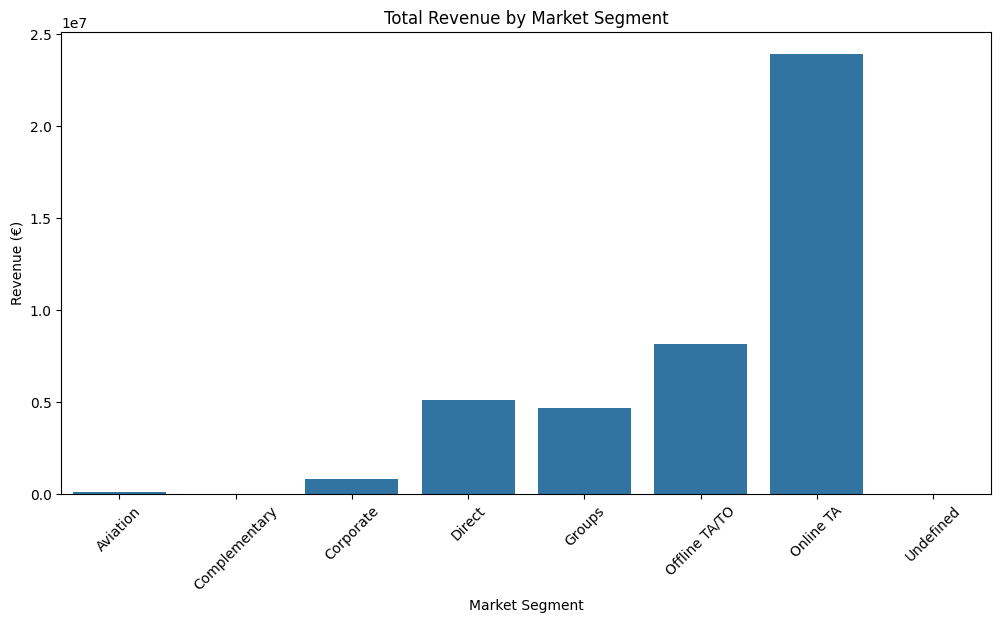

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16536\3205040469.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  room_adr = df.groupby('assigned_room_type')['adr'].mean().sort_values(ascending=False)


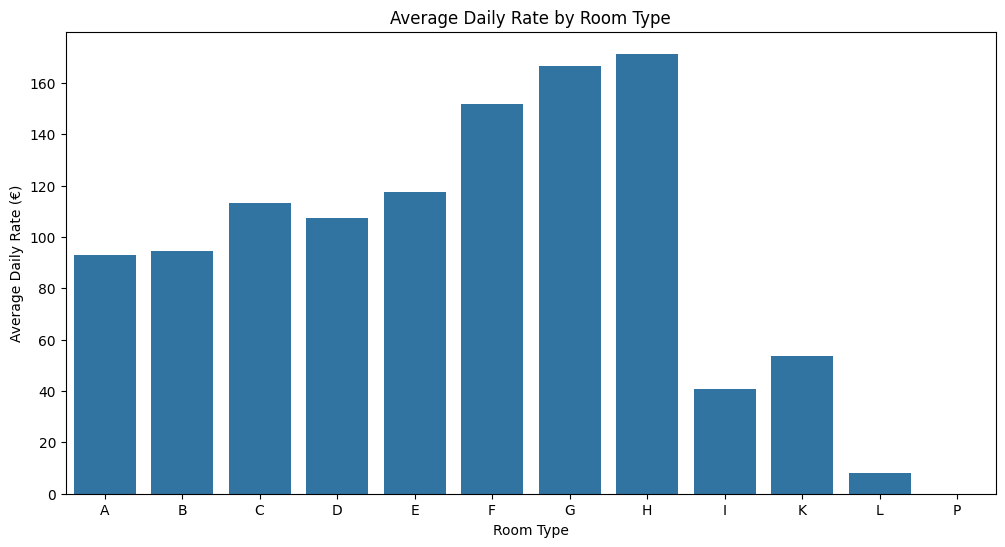

In [9]:
# Revenue by market segment
segment_revenue = df.groupby('market_segment')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=segment_revenue.index, y=segment_revenue.values)
plt.title('Total Revenue by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=45)
plt.savefig('revenue_by_segment.png')
plt.show()

# Average daily rate by room type
room_adr = df.groupby('assigned_room_type')['adr'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=room_adr.index, y=room_adr.values)
plt.title('Average Daily Rate by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Daily Rate (€)')
plt.savefig('adr_by_room.png')
plt.show()

RAG System Implementation

1) Prepare Data for Vectorization

In [10]:
from sentence_transformers import SentenceTransformer

# Create text representations of bookings
def create_booking_text(row):
    text = f"""
    Booking for {row['hotel']} hotel.
    Status: {'Canceled' if row['is_canceled'] else 'Not Canceled'}.
    Dates: {row['arrival_date'].strftime('%Y-%m-%d')} to {row['arrival_date'] + pd.Timedelta(days=row['total_stay'])}.
    Guests: {int(row['total_guests'])} (Adults: {int(row['adults'])}, Children: {int(row['children'])}, Babies: {int(row['babies'])}).
    Room: {row['assigned_room_type']}, originally booked {row['reserved_room_type']}.
    Lead time: {row['lead_time']} days.
    Market segment: {row['market_segment']}.
    Customer type: {row['customer_type']}.
    Country: {row['country']}.
    Deposit: {row['deposit_type']}.
    Revenue: €{row['revenue']:.2f}.
    """
    return text.strip()

# Create text representations (we'll sample for efficiency)
sample_df = df.sample(5000, random_state=42).copy()
sample_df['booking_text'] = sample_df.apply(create_booking_text, axis=1)

# Initialize embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight but effective
embeddings = model.encode(sample_df['booking_text'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2) Set up vector database

In [11]:
import chromadb
from chromadb.config import Settings

# Initialize ChromaDB
client = chromadb.PersistentClient(path="booking_embeddings")  # path is your persistence directory
collection = client.get_or_create_collection("hotel_bookings")

# Add embeddings to collection
ids = [str(i) for i in sample_df.index]
collection.add(
    embeddings=embeddings.tolist(),
    documents=sample_df['booking_text'].tolist(),
    ids=ids
)

5.3) Implement retrieval and LLM integration

In [ ]:
from huggingface_hub import login
#Add your hugging face access token here

In [13]:
from huggingface_hub import snapshot_download
import os

# Path to your model directory
model_path = "C:/Users/ADMIN/Desktop/Assignment"

# Download only the missing config files
snapshot_download(
    repo_id="microsoft/Phi-3-mini-4k-instruct",
    local_dir=model_path,
    allow_patterns=["*.json", "*.py", "*.md"],
    ignore_patterns=["*.safetensors", "*.bin", "*.h5"]  # Skip large files you already have
)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

'C:\\Users\\ADMIN\\Desktop\\Assignment'

In [18]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from pathlib import Path

# Configuration
model_path = Path("C:/Users/ADMIN/Desktop/Assignment")

# 1. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    model_path,
    local_files_only=True
)
tokenizer.pad_token = tokenizer.eos_token

# 2. Load model with CPU-specific settings
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    torch_dtype=torch.float16,  # Use float32 for CPU stability
    device_map="auto",
    trust_remote_code=True,
    low_cpu_mem_usage=True  # Reduces memory spikes
)

# 3. Manual generation function (bypass pipeline issues)
def generate_answer(prompt, max_length=150):
    try:
        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        inputs = tokenizer(formatted_prompt, return_tensors="pt").to('cuda')
        
        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_length,
                do_sample=True,
                temperature=0.7,
                top_p=0.95,
                pad_token_id=tokenizer.eos_token_id,
                use_cache=False
            )
            
        return tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    except Exception as e:
        return f"Error: {str(e)}"

# Test questions
test_questions = [
    "What is the typical lead time for bookings?",
    "Which countries have the most bookings?",
    "What's the average revenue per booking?",
    "What room types generate the highest revenue?"
]

# Run tests
for i, question in enumerate(test_questions, 1):
    print(f"\nQuestion {i}/{len(test_questions)}: {question}")
    print("-"*50)
    answer = generate_answer(question)
    print(f"Answer: {answer}")
    print("="*80)

print("\nAll tests completed!")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu.



Question 1/4: What is the typical lead time for bookings?
--------------------------------------------------
Answer: The typical lead time for bookings can vary widely depending on the service, destination, and provider. However, for many hotels and vacation rentals, the standard lead time for bookings is generally 24 to 36 months in advance, especially for popular destinations during peak travel seasons. For flights, it's recommended to book at least 3-6 months in advance, with the best fares often being secured 11-12 months ahead. For events and experiences, such as cruises or theme parks, it's advisable to book at least 6-12 months in advance, with some requiring even more time due to high demand.

Question 2/4: Which countries have the most bookings?
--------------------------------------------------
Answer: To determine which countries have the most bookings, one would need to analyze data from various sources such as travel websites, hotel booking platforms, and tourism statisti

KeyboardInterrupt: 

API Development with FastAPI

In [19]:
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import json
import os

app = FastAPI(title="Hotel Booking Analytics API")

# CORS setup
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

class QuestionRequest(BaseModel):
    question: str

# Analytics endpoint
@app.post("/analytics")
async def get_analytics():
    try:
        # In a real implementation, we'd generate these dynamically or cache them
        analytics = {
            "monthly_revenue": monthly_revenue.to_dict(),
            "cancellation_rate": cancellation_rate,
            "cancel_by_hotel": cancel_by_hotel.to_dict(),
            "top_countries": top_countries.to_dict(),
            "lead_time_stats": {
                "mean": df['lead_time'].mean(),
                "median": df['lead_time'].median()
            }
        }
        return {"status": "success", "data": analytics}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# Question answering endpoint
@app.post("/ask")
async def answer_question(request: QuestionRequest):
    try:
        answer = rag_query(request.question)
        return {"status": "success", "question": request.question, "answer": answer}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

# To run the API:
# uvicorn main:app --reload

Performance Evaluation

In [20]:
import time
from sklearn.metrics import accuracy_score

# Sample evaluation questions with expected answers
eval_questions = [
    {
        "question": "What is the cancellation rate for City Hotel?",
        "expected_answer": "around 30%",  # Approximate from our data
        "type": "numeric"
    },
    {
        "question": "Which country has the most bookings?",
        "expected_answer": "PRT",  # Portugal
        "type": "fact"
    }
]

def evaluate_system(questions):
    results = []
    for item in questions:
        start_time = time.time()
        answer = rag_query(item["question"])
        latency = time.time() - start_time
        
        # Simple evaluation - in practice you'd want more sophisticated matching
        if item["type"] == "numeric":
            # Extract numbers from answer
            import re
            numbers = re.findall(r"\d+\.?\d*", answer)
            if numbers:
                pred_num = float(numbers[0])
                exp_num = float(re.findall(r"\d+\.?\d*", item["expected_answer"])[0])
                is_correct = abs(pred_num - exp_num) < 5  # Within 5% is acceptable
            else:
                is_correct = False
        else:
            is_correct = item["expected_answer"].lower() in answer.lower()
        
        results.append({
            "question": item["question"],
            "answer": answer,
            "expected": item["expected_answer"],
            "is_correct": is_correct,
            "latency": latency
        })
    
    accuracy = sum([r["is_correct"] for r in results]) / len(results)
    avg_latency = sum([r["latency"] for r in results]) / len(results)
    
    print(f"System Accuracy: {accuracy:.2%}")
    print(f"Average Latency: {avg_latency:.2f} seconds")
    
    return results, accuracy, avg_latency

# Run evaluation
eval_results, accuracy, latency = evaluate_system(eval_questions)

NameError: name 'rag_query' is not defined